## Load Libaries

In [ ]:
from scipy import signal
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import resample
from preprocessing import Filtering
import pandas as pd
from pathlib import Path
import mne

## Constants

In [2]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 2
EEG_HIGHCUT = 32

EMG_NUM_CH = 3          # 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30         # 35
TOTAL_EPOCHS = 90      # 105
TRIAL_PERIOD = 8        # 9

EEG_NAMES = [
"Fp1", "Fp2",   # frontal pole
"C3",  "C4",    # central
"T5",  "T6",    # temporal (posterior)
"Cz",  "Fz",    # occipital
"F7",  "F8",    # temporal (anterior)
"F3",  "F4",    # frontal
"T3",  "T4",    # temporal (mid)
"P3",  "P4"     # parietal
]

## Functions

In [3]:
def preprocessing_routine(raw_eeg, 
                            bandpass_lowcut = 2, 
                            bandpass_highcut = 32, 
                            num_channels = 16, 
                            num_epochs = 30, 
                            trial_period = 9,
                            fs = 125,
                            total_trim_period = 6):
        '''
        Performs the full preprocessing routine:
        1) Notch + Bandpass filter
        2) Resample + z-score standardization + Secmentation into epochs

        :param dict raw_eeg: This holds keys for a specfic class (finger). NOTE - If raw_eeg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
        :param int bandpass_lowcut: Lowpass frequency
        :param int bandpass_highcut: Highpass frequency
        :param int num_channels: Number of activated channels
        :param int num_epochs: Number of epochs (trials) in the dataset
        :param int trial_period: Time of each epoch

        :return dict EEG_norm: Dict with normalized continuous EEG data - EEG_norm[keys()](samples, channels)
        :return dict EEG_epoch: Dict with epoched EEG data - EEG_epoch[keys()](epochs, samples_per_epoch, channels)
        :return dict EEG_epoch_mean: Dict with mean over epochs - EEG_epoch_mean[keys()](samples_per_mean_epoch, channels)
        '''

        # --------------------------------------------------
        # 1) NOTCH + BANDPASS FILTER
        # --------------------------------------------------


        EEG_filter_ins = Filtering(fs = fs)

        EEG_notch = None
        EEG_bandpass = None

        
        EEG_notch = EEG_filter_ins.notch(raw_eeg, cutoff=50, Q=30)
        EEG_bandpass, _ = EEG_filter_ins.butter_bandpass(EEG_notch, lowcut=bandpass_lowcut, highcut=bandpass_highcut, order=4)
        
        n_samples, n_channels = EEG_bandpass.shape
        # --------------------------------------------------
        # 2) RESAMPLE + Z-SCORE STANDARDIZATION + EPOCHING
        # --------------------------------------------------
        EEG_resampled = None
        EEG_norm = None
        
        # Iterate over each dict
        
        total_time = (num_epochs * trial_period) + total_trim_period                                # total time in seconds.
        real_fs = n_samples / (total_time)           # Real frequency
        target_len = int(n_samples  * (fs / real_fs))         # The correct number of samples for desired frequency
        
        EEG_resampled = resample(EEG_bandpass, target_len, axis=0)

        if total_trim_period != 0:
            EEG_trim = trim_dataset_edges(EEG_bandpass, fs=125, trim_start_sec=3, trim_end_sec=3, num_epoch=num_epochs, trial_period=trial_period)
            print(f"trimmed data shape: {EEG_trim.shape}\n")
            EEG_resampled = EEG_trim.copy()

        print(f'Total Time {total_time}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')

        EEG_norm = EEG_filter_ins.zscore_within_channel(EEG_resampled)
        
        return EEG_norm

def trim_dataset_edges(data: np.ndarray, fs: int, trim_start_sec: int, trim_end_sec: int, num_epoch: int, trial_period: int) -> np.ndarray:
    """
    Trims the start and end of the dataset by specified seconds.

    :param data: Input data array of shape (samples, channels)
    :param fs: Sampling frequency in Hz
    :param trim_start_sec: Seconds to trim from the start
    :param trim_end_sec: Seconds to trim from the end
    :return: Trimmed data array
    """
    desired_data_length = fs * num_epoch * trial_period  # 30 seconds * 8 trials
    start_index = trim_start_sec * fs
    end_index = desired_data_length + start_index
    print(f"Start trim idx: {start_index}, End trim idx: {end_index}, Data shape: {data.shape}")
    return data[start_index:end_index].copy()

## TEST MARKER INSERT

In [4]:
file_path = str(Path().resolve().parent) + '/experiment/data/test_markers/EEG/' + 'test_EEG_streaming50' + '.csv'
df = pd.read_csv(file_path)


df.iloc[:, -2] = df.iloc[:, -2] - df.iloc[0, -2]
#time = df.iloc[:, -2]
EEG = df.iloc[:, 1:17].to_numpy()
all_markers = df.iloc[:, -1].to_numpy()

for i, col in enumerate(df.iloc[:, -1]):
    if col > 0:
        print(i, df.iloc[i, -2], df.iloc[i, -1])

0 0.0 101.0
301 2.40419602394104 102.0
302 2.404292106628418 10.0
481 3.84708309173584 20.0
721 5.7695441246032715 30.0
842 6.731317043304443 10.0
962 7.6925880908966064 20.0
1202 9.6166410446167 30.0
1323 10.577543020248413 10.0
1443 11.539752006530762 20.0
1683 13.462380170822144 30.0
1804 14.424598217010498 10.0
1984 15.866887092590332 20.0
2224 17.78969407081604 30.0
2345 18.750766038894653 10.0
2465 19.71384906768799 20.0
2705 21.63615918159485 30.0
2826 22.597326040267944 10.0
2946 23.560007095336914 20.0
3186 25.482065200805664 30.0
3307 26.443796157836914 10.0
3487 27.886667013168335 20.0
3728 29.81013512611389 30.0
3848 30.77119207382202 10.0
3968 31.733119010925293 20.0
4208 33.656288146972656 30.0
4329 34.61779808998108 10.0
4449 35.580294132232666 20.0
4689 37.50309205055237 30.0
4810 38.46539115905762 10.0
4990 39.90639019012451 20.0
5231 41.83025312423706 30.0
5351 42.79111313819885 10.0
5471 43.753172159194946 20.0
5712 45.67649507522583 30.0
5832 46.63849711418152 10.0


In [ ]:
def trim_trial_periods(EEG_bandpass : np.ndarray, all_markers: np.ndarray, markers_idx: np.ndarray, trial_period : int = 8, trim_period : int = 3, fs : int = 125) -> np.ndarray:
    """
    Trims the trial periods from the markers array.
    Parameters
    ----------

    EEG_bandpass : np.ndarray 
        Input of EEG data bandpass filtered
    all_markers : np.ndarray 
        Input of all markers array, including zero values
    markers_idx : np.ndarray
        Indices of non-zero markers. Can be extracted using np.nonzero()[0]
    
    Returns
    ----------
    :return: List of trimmed segments
    """
    # 101 - start first trim
    # 102 - end first trim
    # 10 - start trial
    # 10 - end trial + start new trial
    # 201 - end last trial
    # 202 - end last trim
    enter_trial = False
    enter_trim = False
    period_extrated = False
    st = 0
    ed = 0
    data = EEG_bandpass.copy()
    resampled_data = []

    START_TRIM_MARKER = 101
    END_TRIM_MARKER = 102
    START_TRIAL_MARKER = 10
    END_TRIAL_MARKER = {10, 201}

    # Loop over non-zero indices where markers are present
    for i in range(len(markers_idx)):
        
        # Get the actual index in the markers array plus the next index
        mark_idx = markers_idx[i]
        mark_idx_next = markers_idx[i+1] if i + 1 < len(markers_idx) else None
        
        if mark_idx_next is None:
            continue

        # Enter only at the start of the first trim period
        elif all_markers[mark_idx] == START_TRIM_MARKER and not enter_trim:
            st = mark_idx
            enter_trim = True
        
        # Enter only in the end of the first trim period
        elif all_markers[mark_idx] == END_TRIM_MARKER and enter_trim:
            ed = mark_idx
            period_extrated = True
        
        # Enter only at the start of each trial period
        elif all_markers[mark_idx] == START_TRIAL_MARKER and not enter_trial:
            st = mark_idx
            enter_trial = True
        
        # Enter only in the end of each trial period
        elif all_markers[mark_idx_next] in END_TRIAL_MARKER and enter_trial:
            ed = mark_idx_next
            period_extrated = True
        
        if period_extrated:
            period_extrated = False
            
            if enter_trim:
                trim_data = data[st:ed, :]
                n_samples = trim_data.shape[0]
                real_fs = n_samples / trim_period
                target_len = int(n_samples * (fs / real_fs))
                
                #EEG_resampled = resample(trim_data, target_len, axis=0)
                #resampled_data.append(EEG_resampled)

                enter_trim = False
                print(f'Trial from {st} to {ed}, len: {ed - st}')
                print(f'Time period {trim_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')
                
            
            elif enter_trial:
                trim_data = data[st:ed, :]
                n_samples = trim_data.shape[0]
                real_fs = n_samples // trial_period
                target_len = int(n_samples * (fs / real_fs))

                EEG_resampled = resample(trim_data, target_len, axis=0)
                resampled_data.append(EEG_resampled)
                
                enter_trial = False
                print(f'Trial from {st} to {ed}, len: {ed - st}')
                print(f'Time period {trial_period}\n Real fs: {real_fs} Hz\n Target len: {target_len}\n Original len: {n_samples}')
                
    
    return np.concatenate(resampled_data, axis=0)


In [6]:
def preprocessing_routine_marker(raw_eeg, 
                            bandpass_lowcut = 2, 
                            bandpass_highcut = 32,  
                            trial_period = 9,
                            fs = 125,
                            trim_period = 3,
                            marker_log : list = None):
        '''
        Performs the full preprocessing routine:
        1) Notch + Bandpass filter
        2) Resample + z-score standardization + Secmentation into epochs

        :param dict raw_eeg: This holds keys for a specfic class (finger). NOTE - If raw_eeg is a list, it will be converted to a dict with key 'single_class'. 2D array - Dim(samples, channels)
        :param int bandpass_lowcut: Lowpass frequency
        :param int bandpass_highcut: Highpass frequency
        :param int num_channels: Number of activated channels
        :param int num_epochs: Number of epochs (trials) in the dataset
        :param int trial_period: Time of each epoch

        :return dict EEG_norm: Dict with normalized continuous EEG data - EEG_norm[keys()](samples, channels)
        :return dict EEG_epoch: Dict with epoched EEG data - EEG_epoch[keys()](epochs, samples_per_epoch, channels)
        :return dict EEG_epoch_mean: Dict with mean over epochs - EEG_epoch_mean[keys()](samples_per_mean_epoch, channels)
        '''

        # --------------------------------------------------
        # 1) NOTCH + BANDPASS FILTER
        # --------------------------------------------------


        EEG_filter_ins = Filtering(fs = fs)

        EEG_notch = None
        EEG_bandpass = None
        EEG_trim = None
        EEG_norm = None
        
        EEG_notch = EEG_filter_ins.notch(raw_eeg, cutoff=50, Q=30)
        EEG_bandpass, _ = EEG_filter_ins.butter_bandpass(EEG_notch, lowcut=bandpass_lowcut, highcut=bandpass_highcut, order=4)

        # --------------------------------------------------
        # 2) RESAMPLE + Trim
        # --------------------------------------------------
        markers_idx = np.nonzero(marker_log)[0]
        
        EEG_trim = trim_trial_periods(EEG_bandpass = EEG_bandpass, 
                                        all_markers = marker_log, 
                                        markers_idx = markers_idx, 
                                        trial_period = trial_period, 
                                        trim_period = trim_period, 
                                        fs = fs)
        
        # --------------------------------------------------
        # 3) Z-SCORE STANDARDIZATION
        # --------------------------------------------------
        EEG_norm = EEG_filter_ins.zscore_within_channel(EEG_trim)

        return EEG_norm

In [58]:
EEG_preprocessed = preprocessing_routine_marker(raw_eeg=EEG, 
                            bandpass_lowcut = EEG_LOWCUT, 
                            bandpass_highcut = EEG_HIGHCUT, 
                            trial_period = 4,
                            fs = EEG_FREQ,
                            trim_period = 3,
                            marker_log = all_markers)

EEG_preprocessed[301:25371].shape[0]/(50*4), 4*5*125

Trial from 0 to 301, len: 301
Time period 3
 Real fs: 100.33333333333333 Hz
 Target len: 375
 Original len: 301
Trial from 302 to 842, len: 540
Time period 4
 Real fs: 135 Hz
 Target len: 500
 Original len: 540
Trial from 842 to 1323, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 Original len: 481
Trial from 1323 to 1804, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 Original len: 481
Trial from 1804 to 2345, len: 541
Time period 4
 Real fs: 135 Hz
 Target len: 500
 Original len: 541
Trial from 2345 to 2826, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 Original len: 481
Trial from 2826 to 3307, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 Original len: 481
Trial from 3307 to 3848, len: 541
Time period 4
 Real fs: 135 Hz
 Target len: 500
 Original len: 541
Trial from 3848 to 4329, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 Original len: 481
Trial from 4329 to 4810, len: 481
Time period 4
 Real fs: 120 Hz
 Target len: 501
 

(123.905, 2500)

In [14]:
time_period = df.iloc[301:25371, -2].to_numpy()
new_time = resample(time_period, EEG_preprocessed.shape[0])
# time_df.shape, new_time.shape

EEG_preprocessed.shape, new_time.shape

((25000, 16), (25000,))

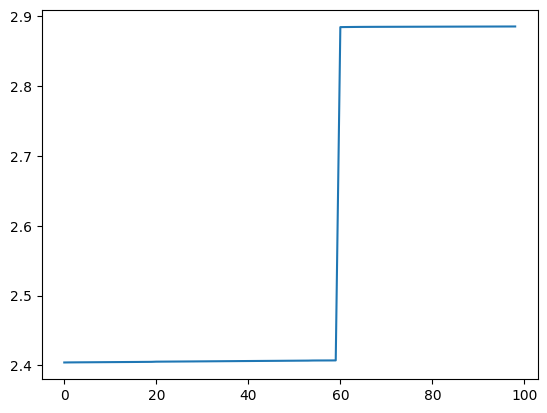

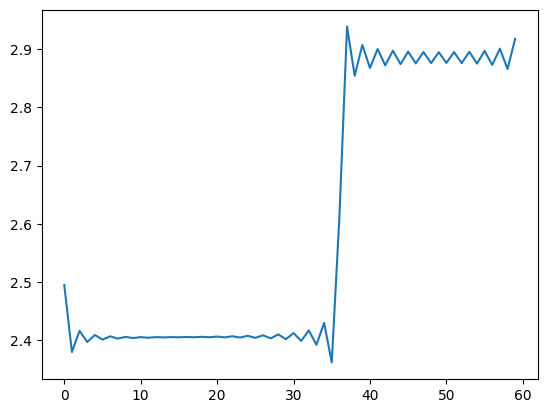

In [59]:
t60 = df.iloc[301:400, -2].to_numpy()
n60 = resample(t60, 60)

plt.figure()
plt.plot(t60)

plt.figure()
plt.plot(n60)

-8.13071189952847e-18 -3.5410988744921665e-19 0.999999999500144 0.999999999499222


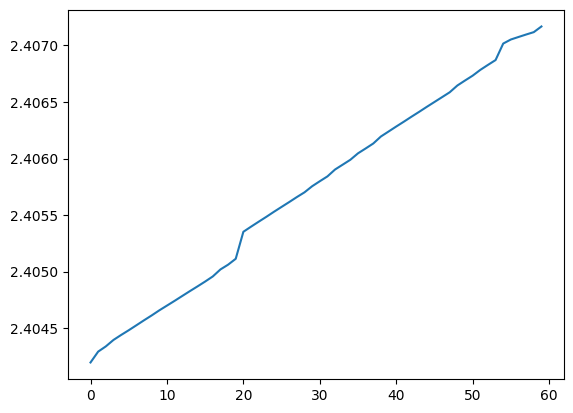

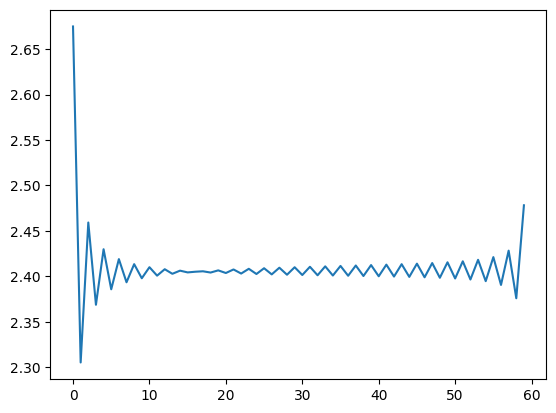

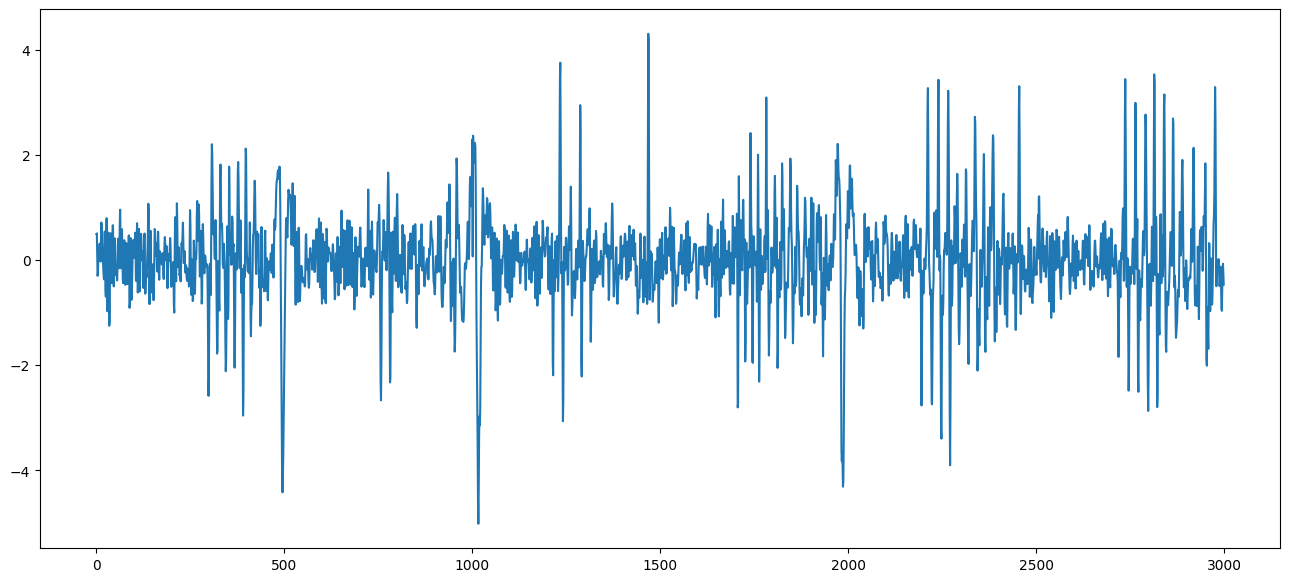

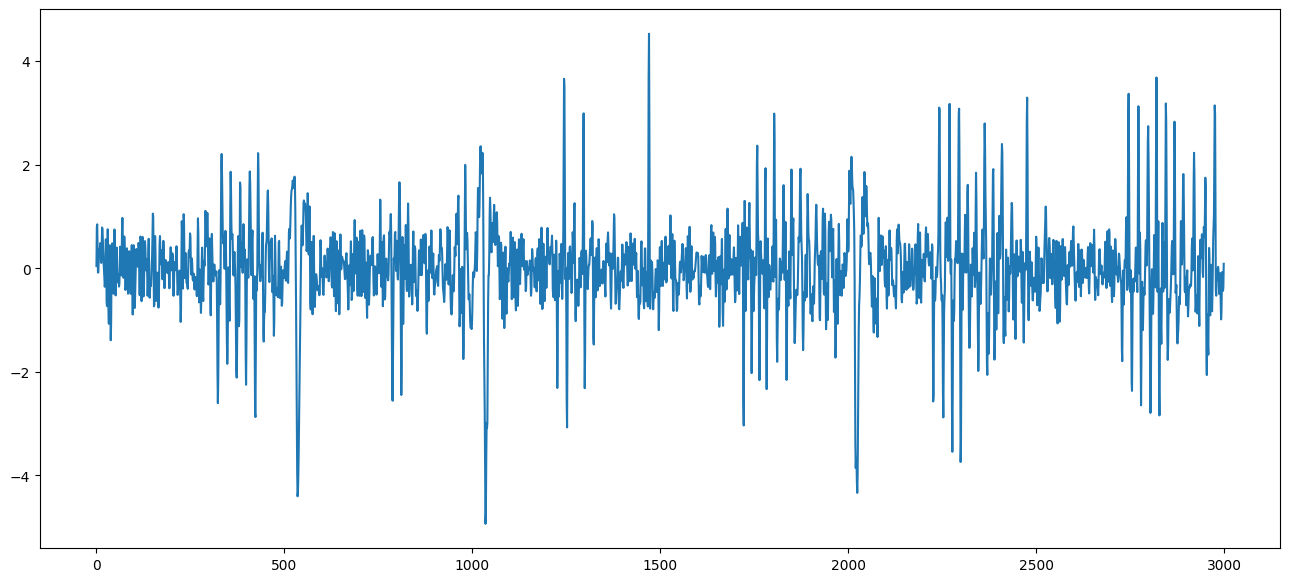

In [60]:
filt = Filtering(125)
notch = filt.notch(df.iloc[301:25371, 1])
bandpass, sos = filt.butter_bandpass(notch, 2, 32, 4)
zscore = filt.zscore_within_channel(bandpass)

print(zscore.mean(), EEG_preprocessed[:, 0].mean(), zscore.std(), EEG_preprocessed[:, 0].std())

plt.figure()
plt.plot(time_period[:60])

plt.figure()
plt.plot(new_time[0:60])

txlim = 3000
perf_time = np.arange(EEG_preprocessed.shape[0]) / EEG_FREQ
plt.figure(figsize=(16, 7))
plt.plot(EEG_preprocessed[:txlim, 0])

plt.figure(figsize=(16, 7))
plt.plot(zscore[:txlim])



In [ ]:

time_perf = np.arange(EEG_preprocessed.shape[0]) / EEG_FREQ
plt.figure(figsize=(14, 8))
plt.plot(time_df[0:125*1], EEG_preprocessed[0:125*1, 3])
#plt.xticks(np.arange(0, new_time[-1], 1))
plt.xlim(0.0, 1.0)
con = [1, 5, 9, 13, 17]
rel = [0, 4, 8, 12, 16]
markers_display = 1
c = 1 
r = 3
for _ in range(markers_display):
    plt.axvline(c, color='green', linestyle='--', linewidth=0.8)
    c += 4
for _ in range(markers_display):
    plt.axvline(r, color='red', linestyle='--', linewidth=0.8)
    r += 4

## Load data

In [ ]:
# For subject_0
data_name = ['flex_index_finger_2026-01-13 14-54-38', 'flex_index_finger_2026-01-13 15-56-27', 'flex_index_finger_2026-01-13 16-02-59']

# For wrist EMG 
#data_name = ['flex_index_finger_2025-11-28 16-41-45', 'flex_index_finger_2025-11-28 16-47-44', 'flex_index_finger_2025-11-28 16-53-44']

all_data = []

for data_nr in range(len(data_name)):
    file_path = str(Path().resolve().parent) + '/experiment/data/subject_0/EEG/' + data_name[data_nr] + '.csv'
    df = pd.read_csv(file_path)
    EEG_raw = df.iloc[:, 1:17].to_numpy()
    print(f"raw data shape: {EEG_raw.shape}")

    # Preprocessing
    EEG_filt = preprocessing_routine(raw_eeg=EEG_raw, 
                            bandpass_lowcut = EEG_LOWCUT,
                            bandpass_highcut = EEG_HIGHCUT,
                            num_channels=EEG_NUM_CH,
                            num_epochs=NUM_EPOCHS,
                            trial_period=TRIAL_PERIOD,
                            fs=EEG_FREQ,
                            total_trim_period=6)

    all_data.append(EEG_filt)

all_data_array = np.array(all_data)
EEG = all_data_array.reshape(-1, EEG_NUM_CH)
print(f"Reshaped data shape: {EEG.shape}")



EEG_samples_per_epoch = EEG.shape[0] // TOTAL_EPOCHS      
print(f"Samples per epoch: {EEG_samples_per_epoch}")

EEG_epoch = EEG.reshape(TOTAL_EPOCHS, EEG_samples_per_epoch, EEG_NUM_CH)

EEG_epoch_mean = EEG_epoch.mean(axis=0)
print(f"Epoched data shape: {EEG_epoch.shape}")
print(f"Mean epoch data shape: {EEG_epoch_mean.shape}")

## Perform ICA

In [ ]:
EEG.shape

In [ ]:
ch_names = [f"ch{i}" for i in range(EEG.shape[1])]
ch_types = ["eeg"] * EEG.shape[1]
sfreq = 125

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = mne.io.RawArray(EEG.T, info)

In [ ]:
ica = mne.preprocessing.ICA(
    n_components=0.77,   # keep 99% variance OR use a fixed number like 15
    method='fastica',
    max_iter = 1000,
    random_state=97
)

reject = dict(eeg = 80)
ica.fit(raw, reject=None)

In [ ]:
plt.figure()
ica.plot_sources(inst = raw, picks = None, start = 0, stop = 240, theme = 'dark')
plt.show(False)

In [ ]:
ica.exclude = [1]
raw_clean = ica.apply(raw.copy())

raw.get_data().shape[1] / 125

In [ ]:
def plot_eeg_stack(data, sfreq, ch_names=None, seconds=240):
    """
    data : (samples, channels)  <-- your X or raw.get_data().T
    seconds : duration to show from start
    """

    n_samples = int(seconds * sfreq)
    data = data[:n_samples]
    time = np.arange(data.shape[0]) / sfreq

    yticks = []
    ylabels = []

    # scale channels to avoid overlap
    offset = np.max(np.abs(data)) * 2

    plt.figure(figsize=(12, 6))
    for i in range(data.shape[1]):
        y_offset = i * offset
        plt.plot(time, data[:, i] + y_offset, linewidth=0.8)

        yticks.append(y_offset)
        if ch_names:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f'ch{i}')

    plt.yticks(yticks, ylabels)
    plt.title("EEG stacked view")
    plt.xlabel("Samples")
    plt.grid(True, axis='x', alpha=0.9)
    plt.xticks(np.arange(0, 20, 1))
    plt.xlim([0, 20])
    plt.show()

plot_eeg_stack(raw_clean.get_data().T, sfreq=125, ch_names = EEG_NAMES)
plot_eeg_stack(raw.get_data().T, sfreq=125, ch_names = EEG_NAMES)

In [ ]:
EEG_samples_per_epoch_mne = len(raw_clean) // TOTAL_EPOCHS      
print(f"Samples per epoch: {EEG_samples_per_epoch_mne}")

EEG_epoch_mne = raw_clean.get_data().T.reshape(TOTAL_EPOCHS, EEG_samples_per_epoch_mne, EEG_NUM_CH)

EEG_epoch_mean_mne = EEG_epoch_mne.mean(axis=0)
print(f"Epoched data shape: {EEG_epoch_mne.shape}")
print(f"Mean epoch data shape: {EEG_epoch_mean_mne.shape}")

# Plot

In [ ]:
def plot_eeg(eeg, fs = 125, n_samples = 1000):
    ymax = np.max(eeg)
    ymin = np.min(eeg)

    fig, axs = plt.subplots(16, 1, figsize=(5, 30), dpi=150)

    time = np.arange(n_samples) / fs

    for ch in range(16):
        ax = axs[ch]
        EEG = eeg[:, ch]

        ax.plot(time, EEG, linewidth=0.5)

        ax.set_ylim([ymin, ymax])

        ax.set_xlabel('Time (s)')
        ax.set_ylabel('EEG')
        ax.legend([EEG_NAMES[ch]], loc='upper right', fontsize='small')

plot_eeg(EEG_epoch_mean_mne, fs=125, n_samples=1000)

# ERD/ERS/MRCP

In [ ]:
import pywt

def compute_ERD_ERS_pfurtscheller(
    epoch,
    fs=125,
    baseline=(0, 2)
):
    """
    Classical Pfurtscheller ERD/ERS (band-power over time)

    Parameters
    ----------
    epoch : np.ndarray
        Shape (n_trials, n_samples, n_channels)
        Must already be band-pass filtered (e.g. 8-30 Hz)
    fs : int
        Sampling frequency
    baseline : tuple
        Baseline interval in seconds (start, end)

    Returns
    -------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
        ERD/ERS (%) over time
    """

    eps = 1e-12

    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    # Instantaneous power
    power = epoch ** 2                        # (trials, samples, channels)

    # Mean across trials
    Act = np.mean(power, axis=0)              # (samples, channels)

    # Baseline reference (per channel)
    R = np.mean(Act[b0:b1, :], axis=0)        # (channels,)

    # ERD / ERS (%)
    erd_ers = (Act - R) / (R + eps) * 100

    return erd_ers

def plot_ERD_ERS(
    erd_ers,
    fs=125,
    channels=None,
    time_window=None,
    title="ERD/ERS (8-30 Hz)"
):
    """
    Plot ERD/ERS as line plots over time

    Parameters
    ----------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
    fs : int
        Sampling frequency
    channels : list or None
        Channel indices to plot (None = all)
    time_window : tuple or None
        (start, end) in seconds
    title : str
    """

    n_samples, n_channels = erd_ers.shape
    time = np.arange(n_samples) / fs

    if time_window is not None:
        t0, t1 = time_window
        idx = (time >= t0) & (time <= t1)
        time = time[idx]
        erd_ers = erd_ers[idx, :]

    if channels is None:
        channels = range(n_channels)

    plt.figure(figsize=(10, 4))

    for ch in channels:
        plt.plot(time, erd_ers[:, ch], label=f"Ch {ch}", linewidth=2)

    plt.axhline(0, color="k", linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("ERD / ERS (%)")
    plt.title(title)
    plt.legend(frameon=False, ncol=3)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def compute_erd_ers_pywt(
    epochs,
    fs=125,
    freq_band=(8, 30),
    baseline=(0, 2),
    wavelet="cmor1.5-1.0"
):
    """
    Compute ERD/ERS using Continuous Wavelet Transform (CWT)

    Parameters
    ----------
    epochs : np.ndarray
        Shape (n_epochs, n_samples, n_channels)
    fs : int
        Sampling frequency (Hz)
    freq_band : tuple
        Frequency band of interest (Hz)
    baseline : tuple
        Baseline interval in seconds (start, end)
    wavelet : str
        Complex Morlet wavelet

    Returns
    -------
    erd_ers : np.ndarray
        Shape (n_samples, n_channels)
        ERD/ERS (%) averaged across epochs and frequencies
    """

    n_epochs, n_samples, n_channels = epochs.shape

    # Frequencies of interest
    freqs = np.linspace(freq_band[0], freq_band[1], 30)

    # Convert frequencies to scales
    scales = pywt.frequency2scale(wavelet, freqs / fs)

    # Baseline indices
    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    erd_ers_all = []

    for ch in range(n_channels):
        power_epochs = []

        for ep in range(n_epochs):
            X_signal = epochs[ep, :, ch]

            coef, _ = pywt.cwt(X_signal, scales, wavelet, sampling_period=1/fs)
            power = np.abs(coef) ** 2     # (freqs, samples)

            power_epochs.append(power)

        power_epochs = np.array(power_epochs)  # (epochs, freqs, samples)

        # Mean across epochs - (freqs, samples)
        power_mean = power_epochs.mean(axis=0)
        

        # Baseline power (per frequency)
        baseline_power = power_mean[:, b0:b1].mean(axis=1, keepdims=True)

        # ERD/ERS (%)
        erd_ers = (power_mean - baseline_power) / baseline_power * 100

        # Average across frequencies (8–30 Hz)
        erd_ers_band = erd_ers.mean(axis=0)  # (samples,)

        erd_ers_all.append(erd_ers_band)

    return np.stack(erd_ers_all, axis=1)  # (samples, channels)

def plot_wavelet_spectrogram(EEG_epochs, fs = 125):
    erd_ers = compute_erd_ers_pywt(epochs=EEG_epochs, fs = fs, freq_band=(8, 30), baseline=(0, 2), wavelet="cmor1.5-1.0")

    plt.figure(figsize=(10, 4))
    plt.imshow(
        erd_ers.T,             # IMPORTANT transpose
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        extent=[0, erd_ers.shape[0]/fs, 0, erd_ers.shape[1]]
    )
    plt.colorbar(label='ERD/ERS (%)')
    plt.xlabel("Time (s)")
    plt.ylabel("Channel")
    plt.title("ERD/ERS (8-30 Hz)")
    plt.show()

def compute_erd_ers_tf_pywt(
    epochs,
    fs=125,
    freq_band=(8, 30),
    n_freqs=30,
    baseline=(0, 2),
    wavelet="cmor1.5-1.0"
):
    """
    Compute time-frequency ERD/ERS per channel using CWT

    Returns
    -------
    erd_ers_tf : np.ndarray
        Shape (channels, freqs, samples)
    freqs : np.ndarray
        Frequencies (Hz)
    """

    n_epochs, n_samples, n_channels = epochs.shape

    freqs = np.linspace(freq_band[0], freq_band[1], n_freqs)
    scales = pywt.frequency2scale(wavelet, freqs / fs)

    b0 = int(baseline[0] * fs)
    b1 = int(baseline[1] * fs)

    erd_ers_tf = np.zeros((n_channels, n_freqs, n_samples))

    for ch in range(n_channels):
        power_epochs = []

        for ep in range(n_epochs):
            coef, _ = pywt.cwt(
                epochs[ep, :, ch],
                scales,
                wavelet,
                sampling_period=1/fs
            )
            power_epochs.append(np.abs(coef) ** 2)

        power_epochs = np.array(power_epochs)   # (epochs, freqs, samples)
        power_mean = power_epochs.mean(axis=0)  # (freqs, samples)

        baseline_power = power_mean[:, b0:b1].mean(axis=1, keepdims=True)

        erd_ers_tf[ch] = (power_mean - baseline_power) / baseline_power * 100

    return erd_ers_tf, freqs

def plot_wavelet_spectrogram_ft(EEG_epochs, ch = 0):
    erd_ers_tf, freqs = compute_erd_ers_tf_pywt(epochs = EEG_epochs, fs = 125, freq_band=(8, 30), n_freqs=30, baseline=(0, 2), wavelet="cmor1.5-1.0")
    time = np.arange(erd_ers_tf.shape[2]) / 125

    plt.figure(figsize=(8, 4))
    plt.imshow(
        erd_ers_tf[ch],
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        extent=[time[0], time[-1], freqs[0], freqs[-1]]
    )
    plt.colorbar(label='ERD/ERS (%)')
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Channel {ch}: Time–Frequency ERD/ERS")
    plt.show()

In [ ]:
ERD = compute_ERD_ERS_pfurtscheller(EEG_epoch_mne, fs = 125)

plot_ERD_ERS(ERD, fs = 125, channels=[2, 3], time_window=None)

In [ ]:
plot_wavelet_spectrogram(EEG_epoch_mne, fs = 125)

## EXPERIMENTS TO TEST
* Only listen to tones (BUT THEY INTRODUCE DELAY...)
* Perform only using text display (Open eyes)
* Is the data shifted reason the trimming implementation?